[2026-07-08 16:11:30] [info     ] 完成: 240225条, 242天
[2026-07-08 16:11:30] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-08 16:11:32] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-08 16:11:33] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-08 16:11:35] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-08 16:11:35] [info     ] ========== 数据检查 ==========
[2026-07-08 16:11:35] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflo

时段,IC
2024-01-15~2024-02-08,0.0033
2024-09-24~2024-10-08,-0.0110

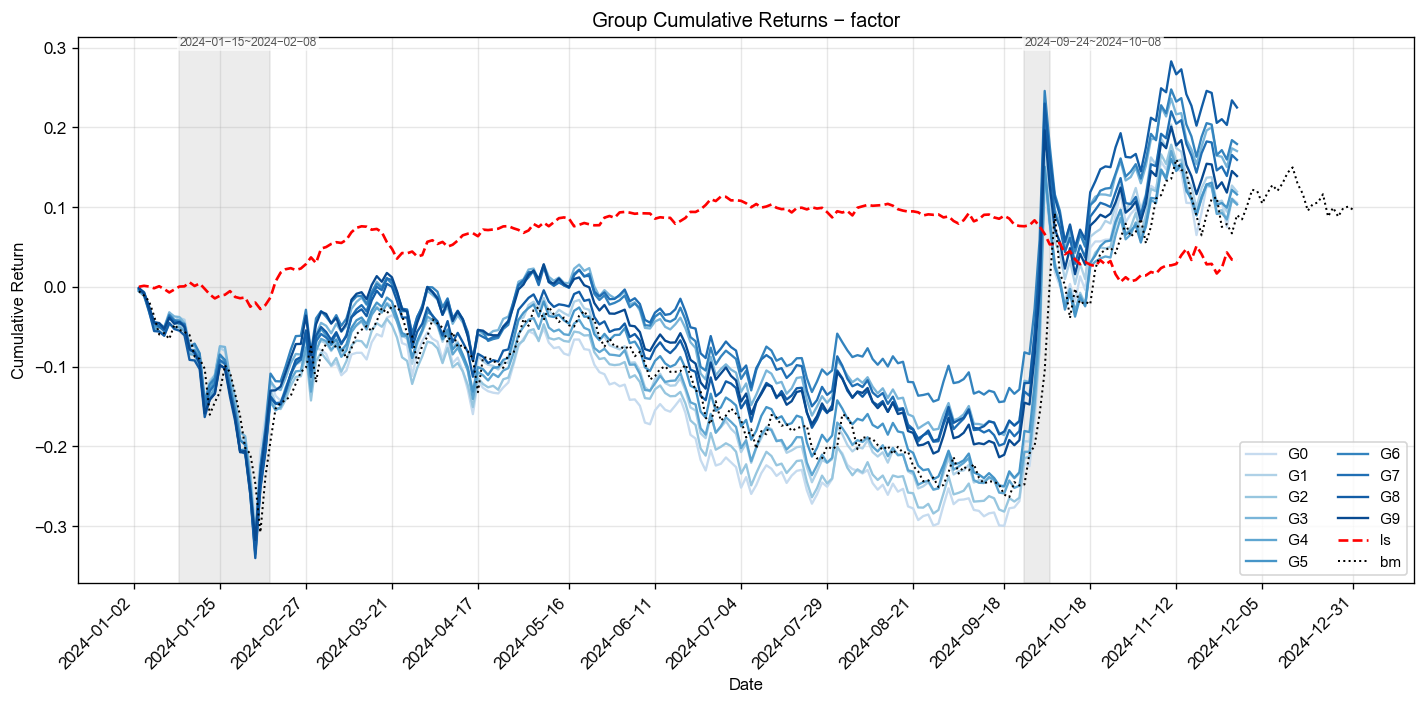
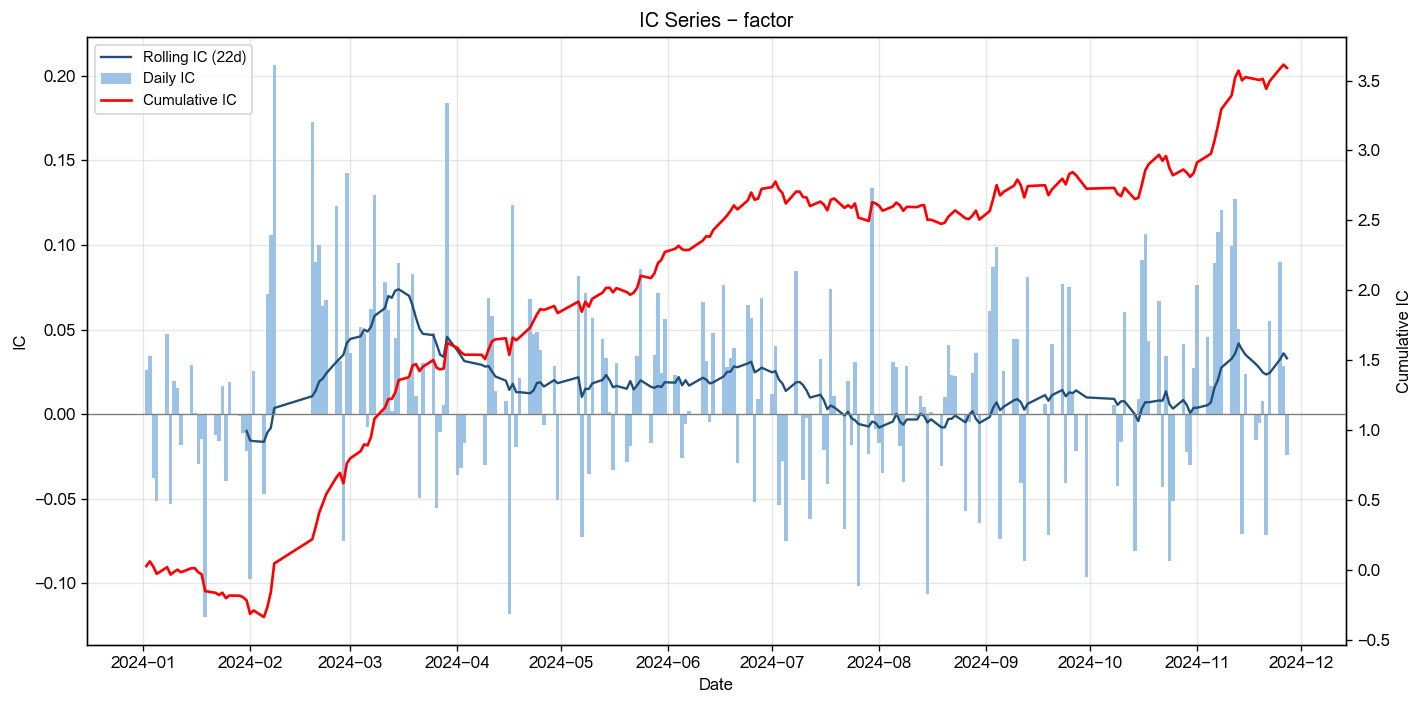
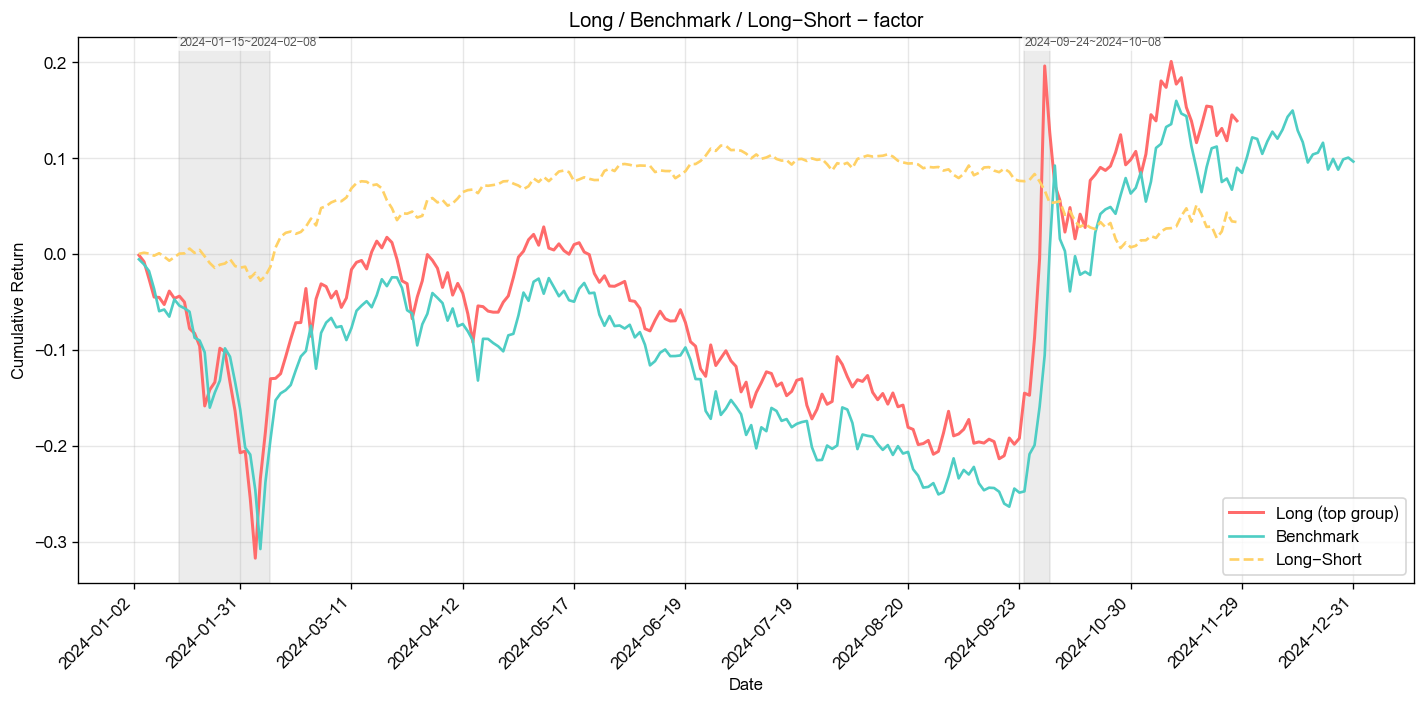
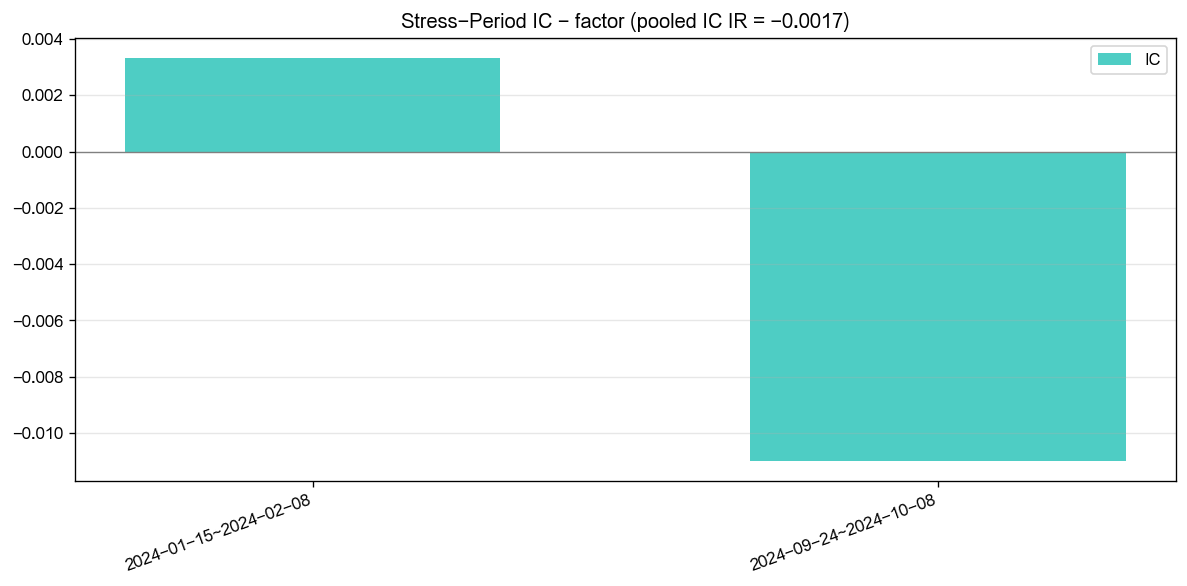
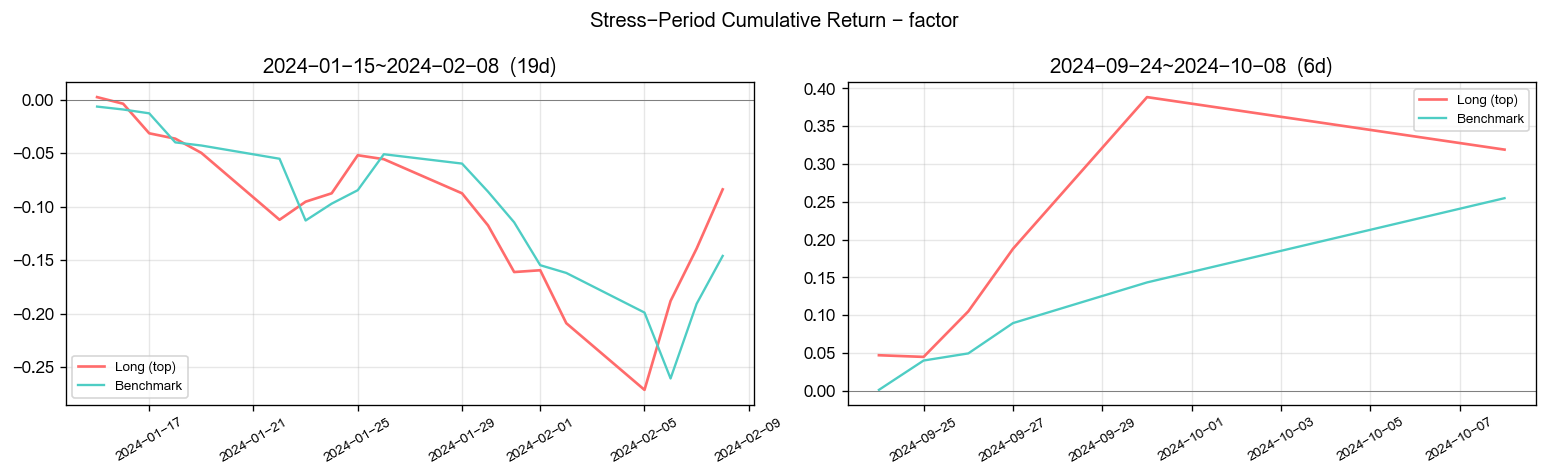

[2026-07-08 16:11:52] [info     ] ========== 因子池回归 ==========
[2026-07-08 16:11:52] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-08 16:11:58] [info     ] 获取收益率数据, 耗时: 6.1747 秒
[2026-07-08 16:11:58] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.4655 秒
[2026-07-08 16:11:58] [info     ] 统计 回归结果, 耗时: 0.0104 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9414,0.0441,0.0227,1.0000
2,amount,1.9145,0.0191,0.0100,1.0000
3,netflow_amount_rate_main,1.5793,0.0092,0.0058,1.0000
4,volume,1.5529,0.0153,0.0099,1.0000
5,netflow_amount_main,1.5185,0.0232,0.0153,1.0000
6,gross_profit_rate_ttm,1.4866,0.0072,0.0048,0.9000
7,ps_ttm,1.4408,0.0035,0.0024,0.9000
8,net_profit_rate_ttm,1.4325,0.0039,0.0027,0.8000
9,cci_14,1.3893,0.0329,0.0237,1.0000
10,bias_20,1.3817,0.0275,0.0199,0.9000

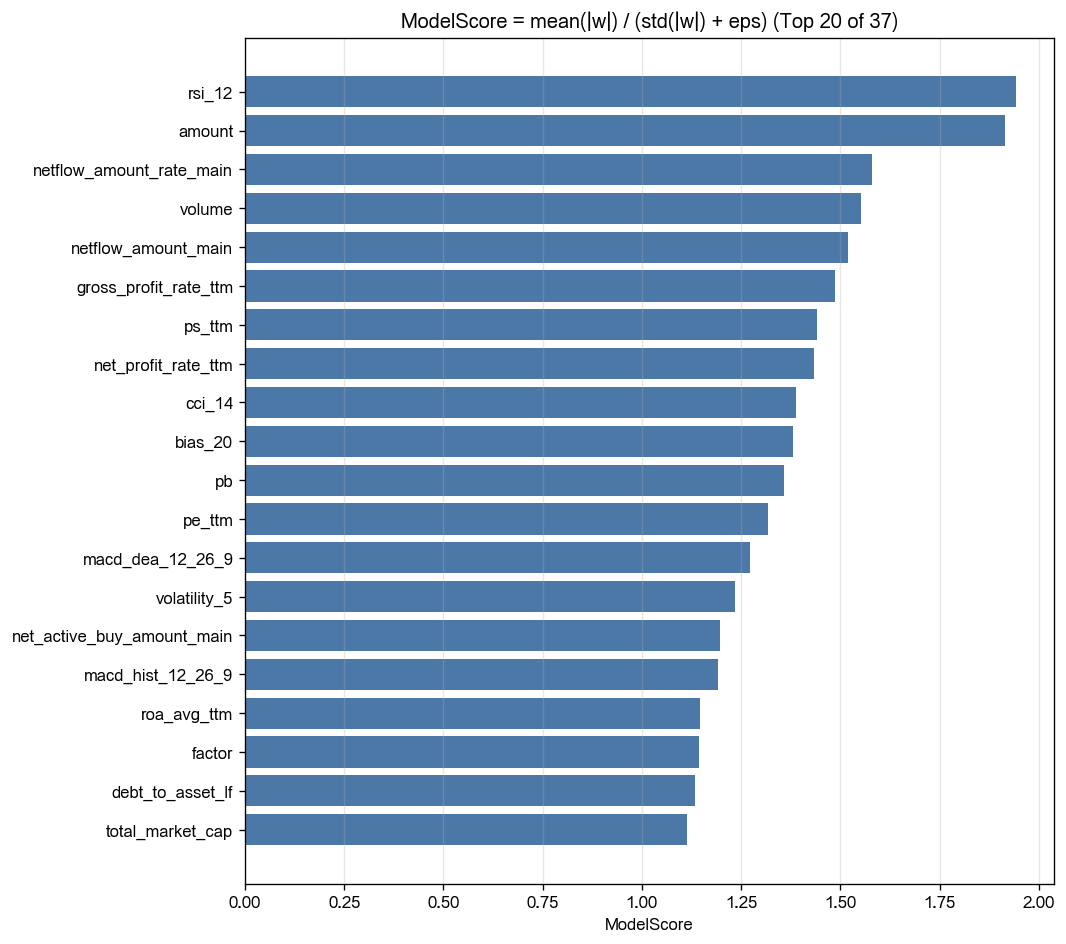
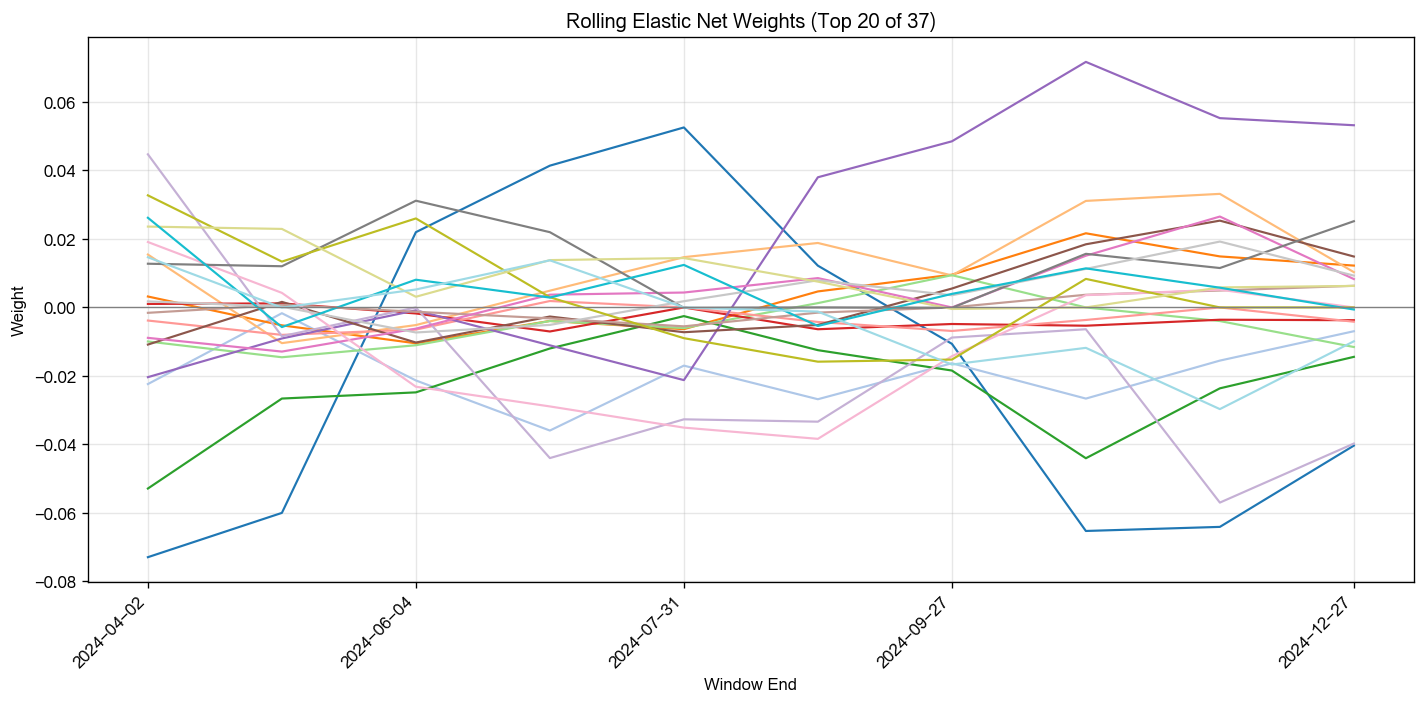
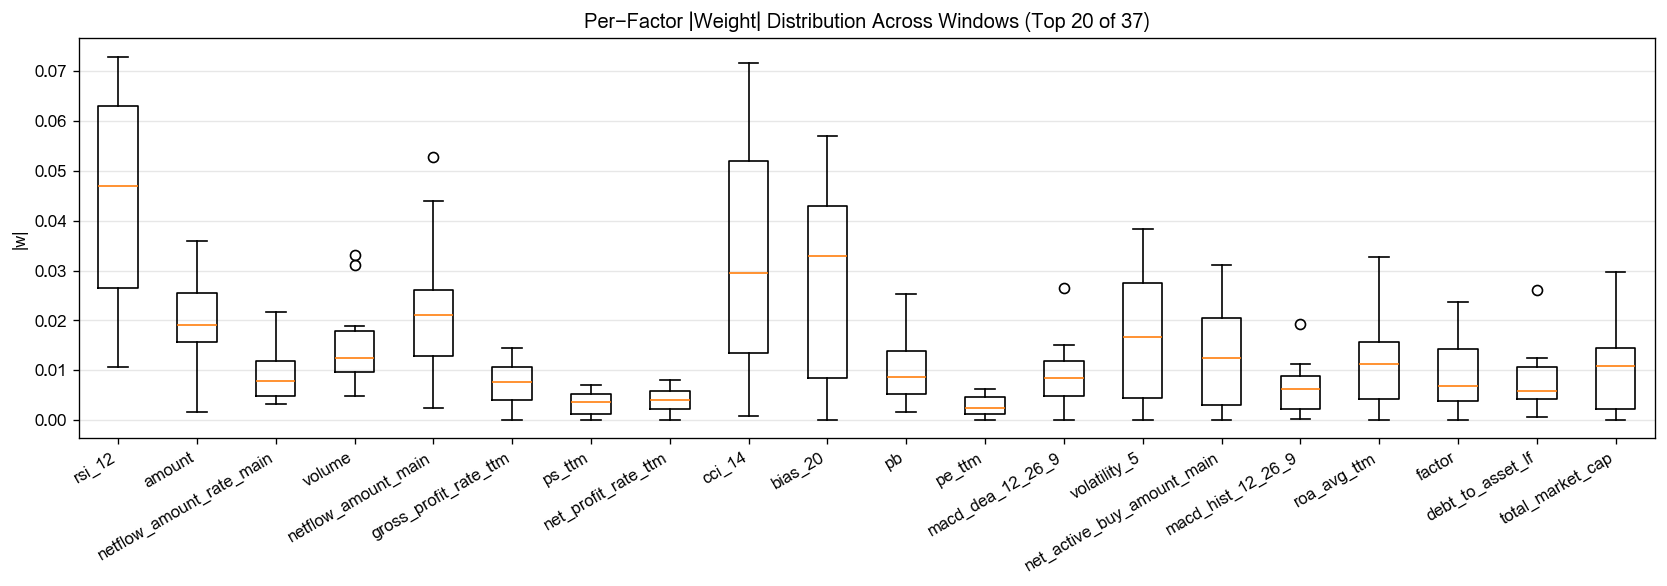
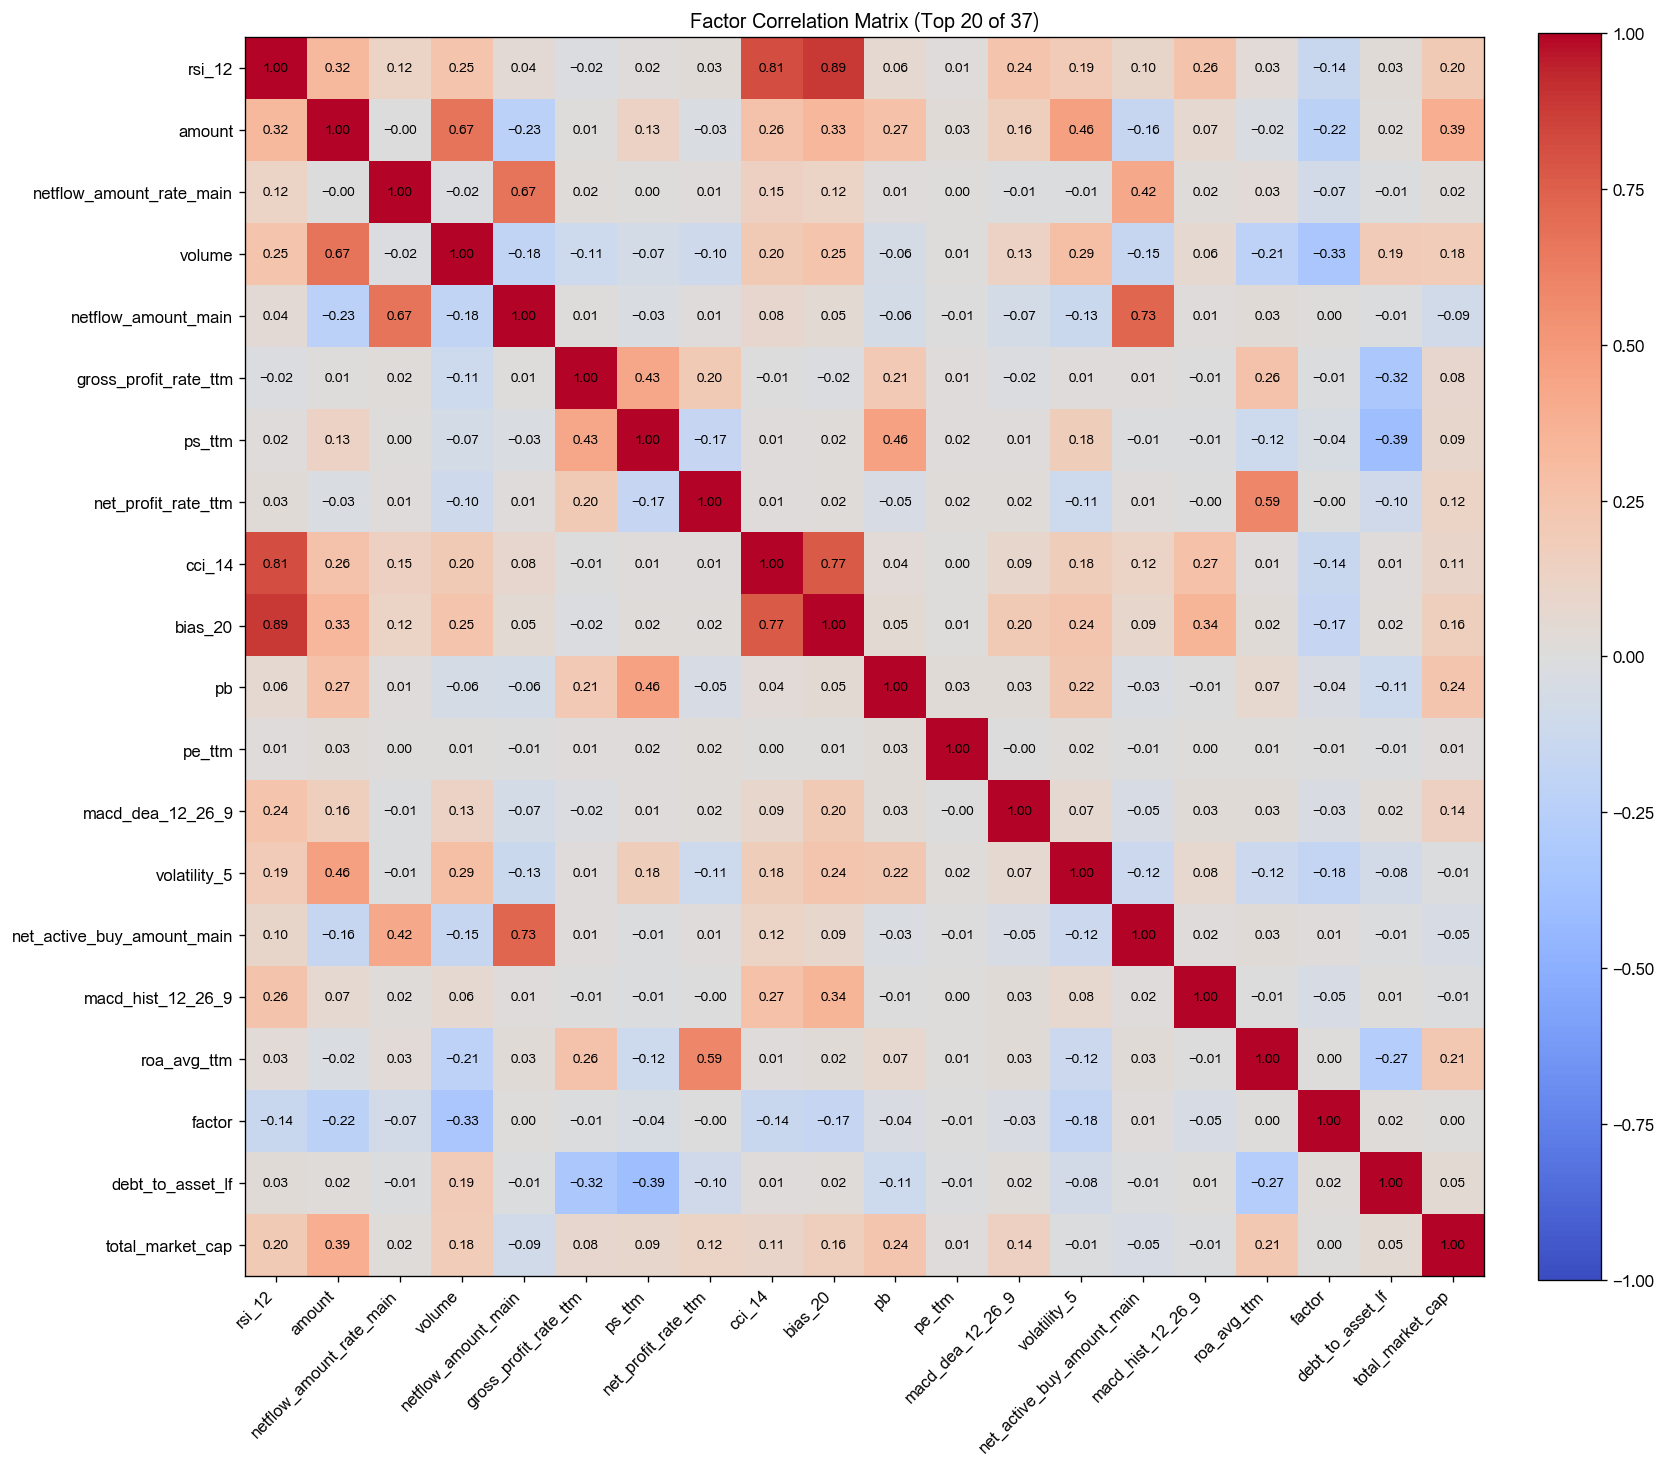

[2026-07-08 16:12:00] [warning  ] 返回的Outputs实例(size=34438996) 大于 64K, 将不会被缓存
[2026-07-08 16:12:00] [info     ] bigalpha_eval.v4 运行完成 [28.041s].


In [2]:
# -*- coding: utf-8 -*-
"""
BigAlpha 2026 AI赛道 — 特征装袋异常检测因子

AI方法: 基于随机子空间采样的集成异常检测（Feature Bagging + Quantile Anomaly）。
核心直觉: 异常点在不同特征子空间中的分布位置偏离正常区域。
纯numpy实现，无需sklearn/GPU，O(n_trees × n × d_feat) 向量化计算。
"""

def main(datasources, start_date, end_date):
    import numpy as np
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]

    FEATURE_COLS = [
        'f01_imb1_mean', 'f02_imb1_std', 'f03_imb5_mean',
        'f04_spread_mean', 'f05_spread_std',
        'f06_depth_ratio', 'f07_log_depth',
        'f08_intraday_ret', 'f09_amplitude', 'f10_intraday_vol',
        'f11_log_volume', 'f12_open_vol_pct', 'f13_close_vol_pct',
        'f14_overnight_gap', 'f15_order_imb',
    ]

    wb = ("COALESCE(bid_volume1,0)*1.0+COALESCE(bid_volume2,0)*EXP(-0.3)"
          "+COALESCE(bid_volume3,0)*EXP(-0.6)+COALESCE(bid_volume4,0)*EXP(-0.9)"
          "+COALESCE(bid_volume5,0)*EXP(-1.2)")
    wa = ("COALESCE(ask_volume1,0)*1.0+COALESCE(ask_volume2,0)*EXP(-0.3)"
          "+COALESCE(ask_volume3,0)*EXP(-0.6)+COALESCE(ask_volume4,0)*EXP(-0.9)"
          "+COALESCE(ask_volume5,0)*EXP(-1.2)")

    sql = f"""
    WITH cte_m AS (
        SELECT date, instrument, strftime(date, '%Y-%m-%d') as td,
            strftime(date, '%H%M') as ts,
            open, high, low, close, pre_close, volume,
            (ask_price1+bid_price1)/2.0 as mid,
            (COALESCE(bid_volume1,0)-COALESCE(ask_volume1,0))
                /NULLIF(COALESCE(bid_volume1,0)+COALESCE(ask_volume1,0),0) as imb1,
            (({wb})-({wa}))/NULLIF(({wb})+({wa}),0) as imb5,
            (ask_price1-bid_price1)/NULLIF((ask_price1+bid_price1)/2.0,0) as spread,
            (COALESCE(bid_volume1,0)+COALESCE(bid_volume2,0)+COALESCE(bid_volume3,0)
             +COALESCE(bid_volume4,0)+COALESCE(bid_volume5,0)) as bd,
            (COALESCE(ask_volume1,0)+COALESCE(ask_volume2,0)+COALESCE(ask_volume3,0)
             +COALESCE(ask_volume4,0)+COALESCE(ask_volume5,0)) as ad,
            (COALESCE(bid_num_orders1,0)+COALESCE(bid_num_orders2,0)+COALESCE(bid_num_orders3,0)
             +COALESCE(bid_num_orders4,0)+COALESCE(bid_num_orders5,0)) as bo,
            (COALESCE(ask_num_orders1,0)+COALESCE(ask_num_orders2,0)+COALESCE(ask_num_orders3,0)
             +COALESCE(ask_num_orders4,0)+COALESCE(ask_num_orders5,0)) as ao
        FROM {bar1m} WHERE ask_price1>0 AND bid_price1>0
    ),
    cte_r AS (SELECT *, mid/NULLIF(lag(mid,1) OVER (PARTITION BY instrument,td ORDER BY date),0)-1 as mr FROM cte_m)
    SELECT CAST(td AS DATETIME) as date, instrument,
        AVG(imb1) as f01_imb1_mean, nanstd(imb1) as f02_imb1_std,
        AVG(imb5) as f03_imb5_mean,
        AVG(spread) as f04_spread_mean, nanstd(spread) as f05_spread_std,
        AVG(bd*1.0/NULLIF(ad,0)) as f06_depth_ratio,
        LN(AVG(bd+ad)+1) as f07_log_depth,
        (LAST(close ORDER BY date)-FIRST(open ORDER BY date))/NULLIF(FIRST(open ORDER BY date),0) as f08_intraday_ret,
        (MAX(high)-MIN(low))/NULLIF(FIRST(open ORDER BY date),0) as f09_amplitude,
        nanstd(mr) as f10_intraday_vol,
        LN(SUM(volume)+1) as f11_log_volume,
        SUM(CASE WHEN ts<='1000' THEN volume ELSE 0 END)*1.0/NULLIF(SUM(volume),0) as f12_open_vol_pct,
        SUM(CASE WHEN ts>='1430' THEN volume ELSE 0 END)*1.0/NULLIF(SUM(volume),0) as f13_close_vol_pct,
        (FIRST(open ORDER BY date)-FIRST(pre_close ORDER BY date))/NULLIF(FIRST(pre_close ORDER BY date),0) as f14_overnight_gap,
        AVG((bo-ao)*1.0/NULLIF(bo+ao,0)) as f15_order_imb,
        COUNT(*) as nb
    FROM cte_r GROUP BY instrument, td HAVING COUNT(*)>=80 ORDER BY date, instrument
    """

    LOOKBACK = 180
    qs = pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK)
    df = dai.query(sql, filters={'date': [qs, end_date]}, compression=True).df()
    if df.empty: raise ValueError("特征为空")

    # ---- 向量化特征装袋异常检测 ----
    def feature_bagging_anomaly(X_train, X_test, n_estimators=60, n_feats=6):
        """
        随机子空间异常检测: 在每个随机特征子集上计算 test 点相对于 train 分布的偏离度。
        全向量化，比树形隔离森林快 50-100 倍。
        """
        n_train = X_train.shape[0]
        n_test = X_test.shape[0]
        n_total_feats = X_train.shape[1]
        scores = np.zeros(n_test)

        for _ in range(n_estimators):
            feats = np.random.choice(n_total_feats, min(n_feats, n_total_feats), replace=False)
            ref_idx = np.random.choice(n_train, min(256, n_train), replace=False)
            X_ref = X_train[ref_idx][:, feats]  # (256, k)
            X_tst = X_test[:, feats]              # (m, k)

            # 向量化百分位计算: 对每个测试点，统计 ref 中小于它的比例
            # X_tst[i] 与 X_ref 全比较: (m, 1, k) < (1, 256, k) → (m, 256, k)
            below = (X_tst[:, None, :] < X_ref[None, :, :]).mean(axis=1)  # (m, k)
            # 偏离度: |percentile - 0.5| 越大越异常
            deviation = np.abs(below - 0.5).mean(axis=1)  # (m,)
            scores += deviation

        return scores / n_estimators

    # ---- 滚动窗口 ----
    all_dates = sorted(df['date'].unique())
    TRAIN_WIN, RETRAIN = 120, 60
    starts = list(range(0, len(all_dates), RETRAIN))
    results = []

    for i, si in enumerate(starts):
        ei = starts[i+1] if i+1 < len(starts) else len(all_dates)
        eval_dates = set(all_dates[si:ei])
        ti = max(0, si - TRAIN_WIN)

        train_mask = df['date'].isin(all_dates[ti:si])
        Xt = df[train_mask].dropna(subset=FEATURE_COLS)[FEATURE_COLS].values.astype(np.float64)
        if len(Xt) < 500: continue

        mu, sg = Xt.mean(0), Xt.std(0) + 1e-8
        Xt_s = (Xt - mu) / sg

        for ed_date in eval_dates:
            ev = df[df['date'] == ed_date].dropna(subset=FEATURE_COLS)
            if len(ev) < 5: continue
            Xe = (ev[FEATURE_COLS].values.astype(np.float64) - mu) / sg
            anom = feature_bagging_anomaly(Xt_s, Xe)
            r = ev[['date', 'instrument']].copy()
            r['raw_factor'] = anom
            results.append(r)

    if not results: raise ValueError("训练失败")
    fd = pd.concat(results, ignore_index=True)

    # ---- 后处理 ----
    fd['factor'] = fd.groupby('date')['raw_factor'].transform(lambda x: x.clip(x.quantile(0.01), x.quantile(0.99)))
    fd['factor'] = fd.groupby('date')['factor'].transform(lambda x: (x-x.mean())/(x.std()+1e-8))
    fd['factor'] = fd['factor'].replace([np.inf,-np.inf], np.nan).fillna(0)

    fd['date'] = pd.to_datetime(fd['date'])
    fd = fd[(fd['date'] >= pd.to_datetime(start_date)) & (fd['date'] <= pd.to_datetime(end_date))]
    stk = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                    filters={'date': [start_date, end_date]}).df()
    stk['date'] = pd.to_datetime(stk['date'])
    fd = pd.merge(fd, stk, how='inner', on=['date', 'instrument'])
    return fd.dropna(subset=['factor'])[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    from bigmodule import M; import dai, structlog
    logger = structlog.get_logger(); ds = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    sd, ed = '2024-01-01 00:00:00', '2024-12-31 23:59:59'
    fd = main(ds, sd, ed)
    logger.info(f"完成: {len(fd)}条, {fd['date'].nunique()}天")
    fp = dai.query("SELECT * FROM bigalpha_2026_factorlib", filters={'date': [sd, ed]}).df()
    M.bigalpha_eval._latest(factor_data=fd, factor_pool=fp, process_pools=False, show=True)
